<h2><center>Assignment 3</center></h2>
<h3><center>Programming for Data Science 2026</center></h3>
<b><center>Deadline: 14:00, March 12, 2026</center></b>

- The exercise will be marked as **passed** if you get **at least 10/16** points.

- Exercises must be handed in via **ILIAS** (Homework assignments). Submit your work as a **compressed (.zip)** file containing **one** `.py` **or** `.ipynb` file with **all exercises**.

- The name of **both** the `.zip` file and the `.py`/`.ipynb` file must be the *SurnameName* of the **two group members**, separated by an underscore.  
  Example: Tim Tabellen and Lara Lambda → `TabellenTim_LambdaLara.zip`  
  (The `.py`/`.ipynb` file must have the same name.)

- Use **comments** to explain your code and demonstrate that you understand the solutions and can discuss them.

- You are not expected to collaborate outside your group. Submitting other groups’ code as your own will result in **0 points**.

- For general questions about the lecture content, assignments, or the exam, please use the **ILIAS forum**.

- For individual questions about lecture content and the exam, contact: *roland.widmer@students.unibe.ch*  

- For individual questions about the exercises or grading, contact: *julien.brunner@students.unibe.ch* or *aline.steiner@students.unibe.ch*

In [3]:
import numpy as np
import time

from numpy.ma.core import argmax

#### Exercise 1: Numpy array from scratch *(1 point)*

Create a numpy array named `numbers` from the list `[1, 2, 4, 5]`.

In [9]:
numbers = np.asarray([1, 2, 4, 5])

Determine datatype and shape of `numbers`.

In [10]:
print(numbers.dtype)
print(numbers.shape)

int64
(4,)


#### Exercise 2: Numpy speed *(2 points)*

We want to calculate the sum of 100 million (!) squared random numbers between 0 and 1. Below a slow implementation:

In [11]:
import numpy as np
time1 = time.time()
random_numbers = np.random.random(100000000)

result = 0
for i in random_numbers:
    result += i ** 2
time2 = time.time()
print(result)

33337541.470691096


Make it faster, by using Numpy's capabilities.

In [13]:
time3 = time.time()
random_numbers = np.random.random(100000000)
result = np.sum(random_numbers**2)
time4 = time.time()
print(result)

print((time2-time1)-(time4-time3))


33334112.626973003
14.787281036376953


#### Exercise 3: Numpy views *(2 points)*

Data sets often contain outliers. In this example, we set a threshold of 10 and replace elements larger than 10 with `np.nan`.

In [14]:
import numpy as np

raw_data = np.array([1.2, 2.3, 20.1, 1.1, 2.2])

cleaned_data = raw_data
cleaned_data[cleaned_data > 10] = np.nan # mark values greater than 10 as missing

print(raw_data)
print(cleaned_data)

[1.2 2.3 nan 1.1 2.2]
[1.2 2.3 nan 1.1 2.2]


Comparing `raw_data` and `clean_data`, we see that the outlier was also removed from `raw_data`.

Explain why this is happening and how we prevent it.

**Your answer:**
raw_data and cleaned_data are pointers to the same object. `cleaned_data[cleaned_data > 10] = np.nan` is a mutation operation on the object. The pointers still point to the same object and hence the updated object value is reflected by both pointers. To prevent this we create a shallow copy and alter it. For example:
```
cleaned_data = raw_data.copy()
cleaned_data[cleaned_data>10] = np.nan
```

#### Exercise 4: Image *(6 points)*

An image consists of $n_{height} * n_{width}$ pixels which all have a color. This color can be represented in three values: red, green, and blue (RGB). The color values are bounded between 0 and 255, while higher values means a brighter color.

Examples: red (255, 0, 0), black (0, 0, 0), white (255, 255, 255)


Run the this cell to load the image and define some helper functions.

(1536, 1024, 3)


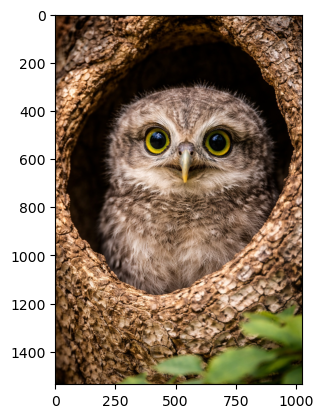

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def load_image(path):
    # you don't need to understand this code (yet...)
    image_data = plt.imread(path)
    image_data = np.array(image_data)
    return image_data

def plot_image(image_data):
    # you don't need to understand this code (yet...)
    plt.imshow(image_data)
    plt.show()



image_data = load_image("../data/images/owl.jpg")

print(image_data.shape)

plot_image(image_data)

Get the number of bytes occupied in memory by a single element of the numpy array. Explain the result.

In [17]:
print(image_data.itemsize)
print(image_data.dtype)

dtype('uint8')

**Your answer**: `image_data` is an np.array object containing the relevant pixel values. These values are made of `uint8` or unsigned integers. These require 8 bits and therefore 1 byte to store. Hence, the byte size of each element in the `np.array` is 1.

Next, we look at a single pixel. Print the the RGB-values at x=538, y=686.

Hint: The first dimension is related to the Y axis, and the second dimension to the X axis.

In [18]:
pixel_at_xy = image_data[686,538]
print(pixel_at_xy)

[242 188  64]


Downsample the image by only considering every 5th pixel (using numpy slicing). Plot the result with the function `plot_image`.

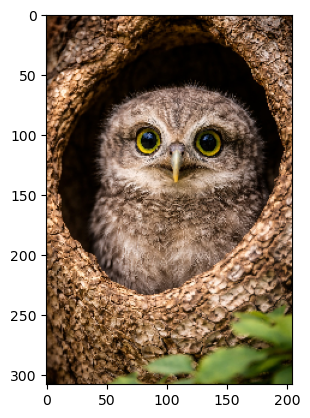

In [19]:
downsampled = image_data[::5,::5]
plot_image(downsampled)

To provide privacy to the owl, create first a copy of the numpy array and assign it to `image_data_anonymized`. Then, create a black bar starting at pixel x=330, y=500 with a black of height 79 px and width 423 px. Plot the result with the function `plot_image`.

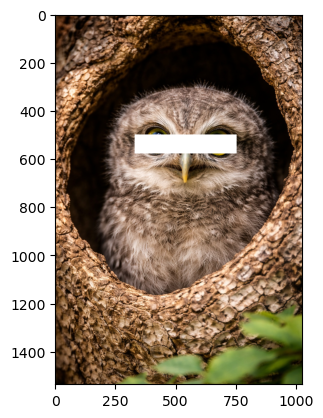

In [26]:
image_data_anonymized = image_data.copy()
image_data_anonymized[500:579, 330:753, : ] = [255,255,255]
plot_image(image_data_anonymized)

Flip the original image horizontally (left to right) and plot the result.

Hint: Have a look at the [documentation](https://numpy.org/doc/stable/reference/routines.array-manipulation.html) to find the appropriate function.

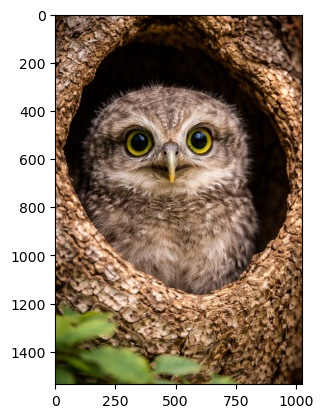

In [27]:
flipped = image_data[:, ::-1]
plot_image(flipped)

Convert the image to grayscale using the luminosity method: $\text{gray} = 0.2989 \times R + 0.5870 \times G + 0.1140 \times B$. Plot the result.

Hint: Greyscale has to be converted back to RGB.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..253.0025].


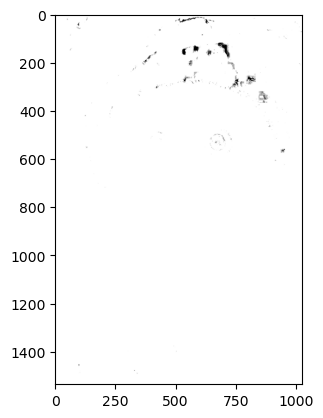

In [34]:
grey = [0.2989, 0.5870, 0.1140]
greyed = np.dot(image_data, grey)
plot_image(np.stack([greyed]*3, axis=-1))


#### Exercise 5: Timeseries *(5 points)*

In this exercise, we work with daily water temperature data from the Aare river in Bern. 

Source: [Hydrology Division, Federal Office for the Environment FOEN (2026)](https://www.hydrodaten.admin.ch/en/seen-und-fluesse/messstationen-temperatur).

First, we define some helper functions:

- `get_daily_temperature_data`: returns the daily temperature data for a given year
- `get_monthly_temperature_data`: returns the monthly average temperature for all available years
- `plot_temperature`: plots the the temperature for a given numpy array

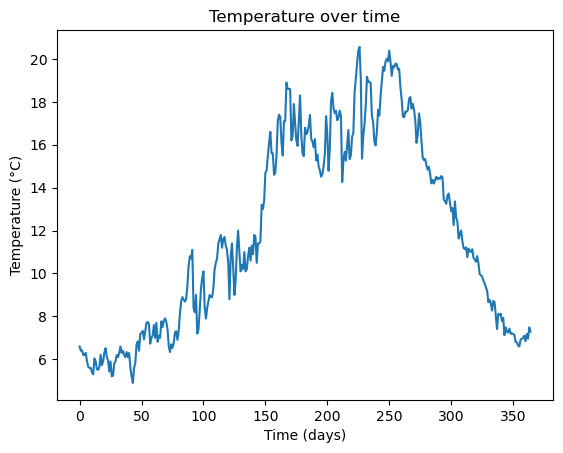

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def get_daily_temperature_data(year: int):
    # you don't need to understand this code (yet...)
    temperature_df = pd.read_csv(f"../data/csv/aare_temperature.csv", parse_dates=["timestamp"])

    temperature_df = temperature_df[temperature_df["timestamp"].dt.year == year]
    
    return temperature_df["value"].to_numpy()

def get_monthly_temperature_data():
    # you don't need to understand this code (yet...)
    temperature_df = pd.read_csv(
        "../data/csv/aare_temperature.csv",
        parse_dates=["timestamp"]
    )

    temperature_df["year"] = temperature_df["timestamp"].dt.year
    temperature_df["month"] = temperature_df["timestamp"].dt.month

    grouped = (
        temperature_df
        .groupby(["year", "month"])["value"]
        .mean()
        .unstack("month")
        .sort_index()
    )

    return grouped.to_numpy()


def plot_temperature(temperature_data, time_unit="days"):
    # you don't need to understand this code (yet...)
    plt.plot(temperature_data)
    plt.xlabel(f"Time ({time_unit})")
    plt.ylabel("Temperature (°C)")
    plt.title(f"Temperature over time")
    plt.show()


temperature_2021 = get_daily_temperature_data(2021)
plot_temperature(temperature_2021)


Get the temperatures using `get_daily_temperature_data` from 2024 and 2025 and store it in a single 1d-numpy array. Plot the result using `plot_temperature`.

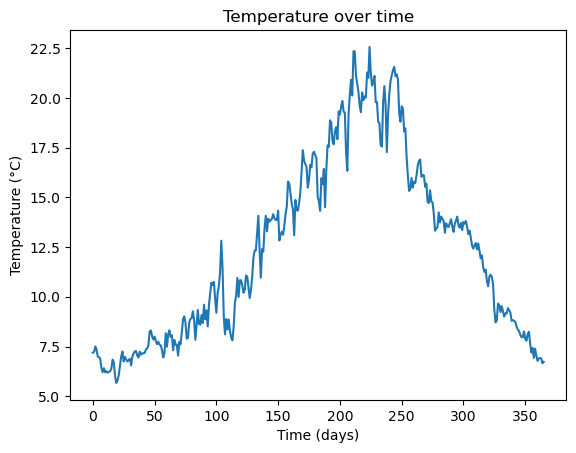

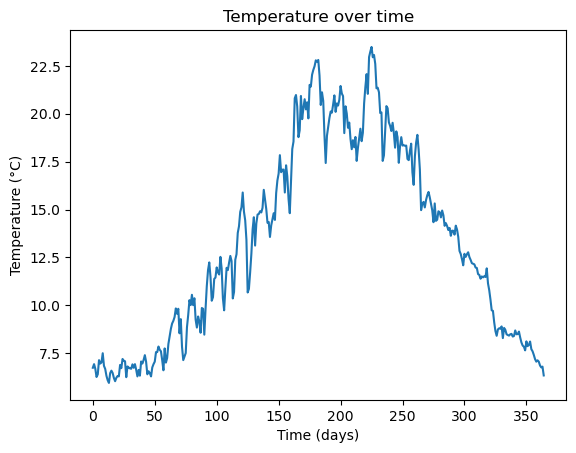

In [5]:
temp_2024 = np.asarray(get_daily_temperature_data(2024))
temp_2025 = np.asarray(get_daily_temperature_data(2025))
plot_temperature(temp_2024)
plot_temperature(temp_2025)

Get the minimum, maximum and mean temperature across the two years.

In [6]:
print(f"2024:{temp_2024.mean(),
temp_2024.min(),
temp_2024.max()},temp 2025:{
temp_2025.mean(),
temp_2025.min(),
temp_2025.max()}")

2024:(np.float64(12.34734972677596), np.float64(5.67), np.float64(22.56)),temp 2025:(np.float64(13.196958904109588), np.float64(5.95), np.float64(23.49))


Implement code that calculates the days, on which the minimum and the maximum temperature was reached. You can give the result in days passed since the January 1, 2024.

Example: Highest temperature was reached on the January 3, 2024. Answer: 2

Hint: Have a look at the [documentation](https://numpy.org/doc/2.3/reference/routines.sort.html#searching).

In [29]:
from datetime import datetime , timedelta
def get_date_min_max(year: int):
    data = np.asarray(get_daily_temperature_data(year))
    day_min = int(np.argmin(data))
    day_max = int(np.argmax(data))
    day_start = datetime(year=year, month=1, day=1)
    date_max = datetime.date( day_start+ timedelta(days=day_max)).strftime("%B-%d-%Y")
    date_min = datetime.date(day_start + timedelta(days=day_min)).strftime("%B-%d-%Y")
    print(f"The highest Temperature was reached on: {date_max} and the lowest Temperature was reached on: {date_min}")

get_date_min_max(2024)


The highest Temperature was reached on: August-12-2024 and the lowest Temperature was reached on: January-20-2024


Use `get_monthly_temperature_data` to get monthly average temperatures from years 2004 up to 2025. Calculate the mean temperature per month and plot it with `plot_temperatures` (with `time_unit="months"`).

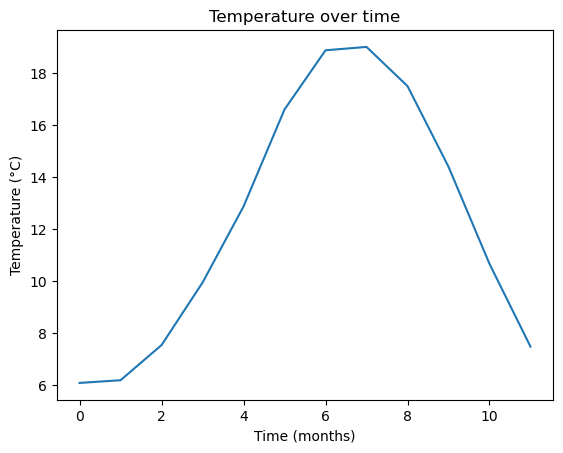

In [38]:
#def avg_temp():
def get_monthly_mean():
    data = get_monthly_temperature_data()
    monthly_mean = np.mean(data, axis=0)
    plot_temperature(monthly_mean,time_unit="months")

get_monthly_mean()



Calculate the yearly average per year. From this, the year with the maximum average water temperature.

In [41]:
def yearly_mean():
    data = get_monthly_temperature_data()
    yearly_mean = np.mean(data, axis=1)
    return yearly_mean
yearly_means = yearly_mean()
year = 2004+np.argmax(yearly_means)
year

np.int64(2022)